## Neural Network Model #1: **Multi-Layer Perceptron**

First, we will import our pre-split and scaled training, validation, and test sets.

In [22]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import numpy as np

# make sure torch is installed
import sys
!{sys.executable} -m pip install torch

# Load the preprocessed and scaled data
X_train_scaled = joblib.load('processed_data/X_train_scaled.pkl')
X_val_scaled = joblib.load('processed_data/X_val_scaled.pkl')
X_test_scaled = joblib.load('processed_data/X_test_scaled.pkl')

y_train = joblib.load('processed_data/y_train.pkl')
y_val = joblib.load('processed_data/y_val.pkl')
y_test = joblib.load('processed_data/y_test.pkl')

In [23]:
from MCO_functions import trainNetwork, evaluateNetwork
from MCO_functions import DataLoader
from MCO_functions import NeuralNetwork
import torch.optim as optim
import torch.nn as nn
import numpy as np

# Ensure deterministic behavior for reproducibility
import torch, numpy as np, random, os

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
# load data into PyTorch tensors
nn_X_train = torch.from_numpy(X_train_scaled.to_numpy()).float()
nn_y_train = torch.from_numpy(y_train.to_numpy()).long()

nn_X_val = torch.from_numpy(X_val_scaled.to_numpy()).float()
nn_y_val = torch.from_numpy(y_val.to_numpy()).long()

nn_X_test = torch.from_numpy(X_test_scaled.to_numpy()).float()
nn_y_test = torch.from_numpy(y_test.to_numpy()).long()

# determine input size based on features in X train
input_size = nn_X_train.shape[1]
input_size

81

# **[4]** Model Selection Training


In predicting urban and rural households, we employ a multi-layer perceptron, as these are known to be effective at handling non-linear problems and large datasets.

https://www.datacamp.com/tutorial/multilayer-perceptrons-in-machine-learning  
https://h2o.ai/wiki/multilayer-perceptron/  

To get more effective final model, we accomplish the following:

1. Preliminary comparison of different neural network architectures
2. Comparison of hyperparameter configurations of the selected architecture(s)
3. Error analysis of the selected model and tuning

### Preliminary Comparison of different Neural Network Architectures

Rectified Linear Units (ReLu) is used as the activation function in training the neural networks for its less expensive computation compared to sigmoid. Adam is used as the optimizer.
$$
ReLU(x)=max(0,x)
$$

$$
f(x)=
\begin{cases}
0 & \text{if } x < 0 \\
1 & \text{if } x \geq 0 
\end{cases}
$$  

We perform an initial grid search over different possible neural network architectures and compare their performance metrics in order to get a better configuration for the final model. These architectures follow the pyramid pattern, where after the first hidden layer, each layer has half the neurons of the previous. This approach is known to be more effective for tabular data.  

https://machinelearningtheory.org/docs/Deep-Learning/designing-the-architecture/  

An initial learning rate of 0.005 and a relatively smaller epoch limit of 15 is used to speed up the preliminary search. Each network architecture is trained and evaluated using multiple seeds, with each of their resulting metrics averaged to provide more stable performance estimates.

In [25]:
learning_rate = 0.005
# a relatively small epoch limit to prevent long training times during preliminary search
epoch_limit = 15

seeds = [0, 42, 123, 456, 789]  # different for multiple runs

# Define different architectures to test (number of hidden layers and their sizes)
configs = [
    (64, 32),
    (128, 64),
    (256, 128),
    (128, 64, 32),
    (256, 128, 64)
]

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train and evaluate the neural network for each architecture configuration
criterion = nn.CrossEntropyLoss()
data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=64)

for hidden_layers in configs:

    run_metrics = []  # to store metrics for this architecture

    for seed in seeds:
        # Set seeds for reproducibility
        os.environ['PYTHONHASHSEED'] = str(seed)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.use_deterministic_algorithms(True)

        network = NeuralNetwork(
            input_size=input_size,
            list_hidden=hidden_layers,
            activation='relu',
            num_classes=2
        )

        print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}")

        network.create_network()

        optimizer = optim.Adam(network.parameters(), lr=learning_rate)

        training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

        loss_history.append({
            "architecture": hidden_layers,
            "seed": seed,
            "losses": training_losses
        })

        # evaluate on both train and validation sets
        trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
        evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)

        # store metrics of this run
        run_metrics.append({
            "train": trainMetrics,
            "val": evalMetrics
        })

    # compute averages across runs
    avg_train_metrics = {}
    for k, v in run_metrics[0]["train"].items():
        if isinstance(v, dict):  # nested dict
            for subk in v:
                avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
        else:  # simple float
            avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
    
    avg_val_metrics = {}
    for k, v in run_metrics[0]["val"].items():
        if isinstance(v, dict):
            for subk in v:
                avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
        else:
            avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])

    # append averaged results for this architecture
    results.append({
        "architecture": hidden_layers,
        **{"train_" + k: v for k, v in avg_train_metrics.items()},
        **{"val_" + k: v for k, v in avg_val_metrics.items()}
    })


Training Neural Network with hidden layers: (64, 32), seed: 0
Epoch: 1 	Loss: 0.421367
Epoch: 2 	Loss: 0.391790
Epoch: 3 	Loss: 0.380237
Epoch: 4 	Loss: 0.370955
Epoch: 5 	Loss: 0.363455
Epoch: 6 	Loss: 0.354974
Epoch: 7 	Loss: 0.347686
Epoch: 8 	Loss: 0.338864
Epoch: 9 	Loss: 0.332548
Epoch: 10 	Loss: 0.327677
Epoch: 11 	Loss: 0.319671
Epoch: 12 	Loss: 0.315008
Epoch: 13 	Loss: 0.308115
Epoch: 14 	Loss: 0.303487
Epoch: 15 	Loss: 0.297070

Training Neural Network with hidden layers: (64, 32), seed: 42
Epoch: 1 	Loss: 0.419124
Epoch: 2 	Loss: 0.391798
Epoch: 3 	Loss: 0.381512
Epoch: 4 	Loss: 0.371827
Epoch: 5 	Loss: 0.364041
Epoch: 6 	Loss: 0.356715
Epoch: 7 	Loss: 0.350151
Epoch: 8 	Loss: 0.342016
Epoch: 9 	Loss: 0.337097
Epoch: 10 	Loss: 0.330634
Epoch: 11 	Loss: 0.323760
Epoch: 12 	Loss: 0.315569
Epoch: 13 	Loss: 0.311487
Epoch: 14 	Loss: 0.304874
Epoch: 15 	Loss: 0.298124

Training Neural Network with hidden layers: (64, 32), seed: 123
Epoch: 1 	Loss: 0.420923
Epoch: 2 	Loss: 0.391

Each architecture's change in loss throughout training is visualized using a line graph.

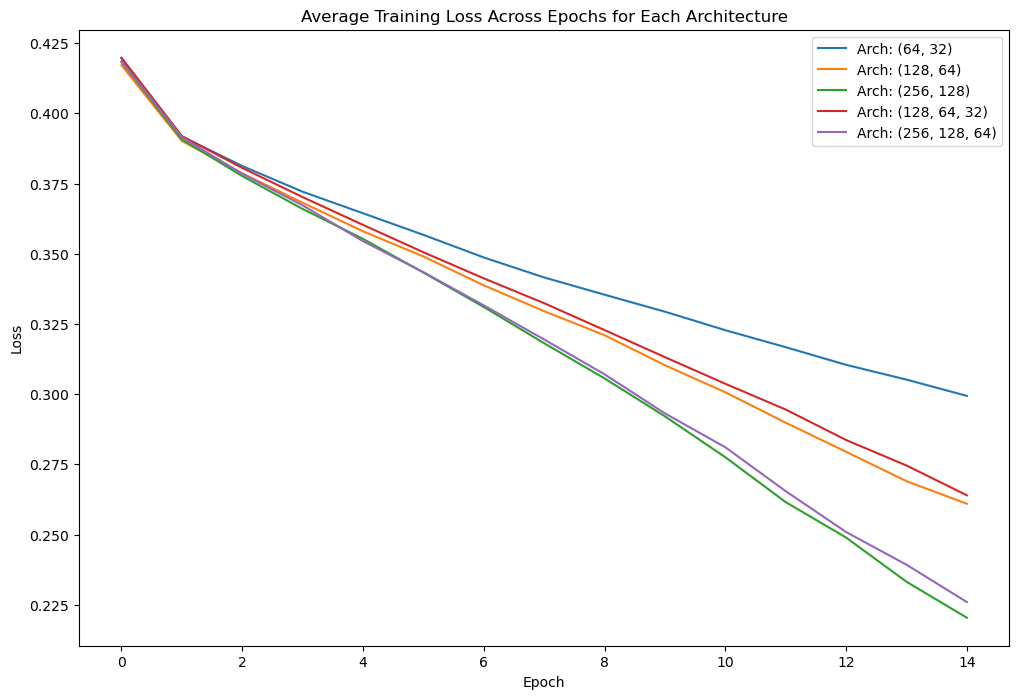

In [26]:
# graph loss history for each architecture (averaged across seeds)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for config in configs:
    # filter loss history for this architecture
    config_history = [h for h in loss_history if h["architecture"] == config]

    min_len = min(len(h["losses"]) for h in config_history)

    aligned_losses = [
        h["losses"][:min_len] for h in config_history
    ]
    
    # average losses across seeds
    avg_losses = np.mean(aligned_losses, axis=0)
    
    plt.plot(avg_losses, label=f"Arch: {config}")

plt.title("Average Training Loss Across Epochs for Each Architecture")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **[5]** Error Analysis and Model Tuning

For each class, precision, recall, and f1-scores are used as metrics along with **balanced accuracy** instead of classic accuracy. Balanced accuracy, which is the average of the recall on each class, is more effective for classification problems on imbalanced sets. Between the **urban (class 1)** and **rural (class 0)** classes in the dataset, rural is the majority class. For the duration of the development of the multi-layer perceptron, any mention of the term accuracy will refer to balanced accuracy.  

$$\text{Balanced Accuracy} = \frac{1}{k} \sum_{i=1}^{k} \text{Recall}_i$$

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html

In [27]:
# flatten results of comparing different architectures
def flat_results_architecture(training_results):
    results_flat = []
    for r in training_results:
        flat_r = {
            "architecture": r["architecture"],
            "train_accuracy": r["train_accuracy"],
            "train_precision_rural": r["train_precision_class 0"],
            "train_precision_urban": r["train_precision_class 1"],
            "train_recall_rural": r["train_recall_class 0"],
            "train_recall_urban": r["train_recall_class 1"],
            "train_f1_rural": r["train_f1_class 0"],
            "train_f1_urban": r["train_f1_class 1"],
            "train_log_loss": r["train_log_loss"],
            "train_ROC_AUC": r["train_ROC_AUC"],
            "train_PR_AUC": r["train_PR_AUC"],
            "val_accuracy": r["val_accuracy"],
            "val_precision_rural": r["val_precision_class 0"],
            "val_precision_urban": r["val_precision_class 1"],
            "val_recall_rural": r["val_recall_class 0"],
            "val_recall_urban": r["val_recall_class 1"],
            "val_f1_rural": r["val_f1_class 0"],
            "val_f1_urban": r["val_f1_class 1"],
            "val_log_loss": r["val_log_loss"],
            "val_ROC_AUC": r["val_ROC_AUC"],
            "val_PR_AUC": r["val_PR_AUC"],
        }
        results_flat.append(flat_r)
    return results_flat

The training and validation metrics of each tested architecture is displayed in tabular form. Training and validation accuracy for each architecture is represented in a bar chart.

In [28]:
results_flat = flat_results_architecture(results)
results_df = pd.DataFrame(results_flat)
results_df.T

,0,1,2,3,4
architecture,"(64, 32)","(128, 64)","(256, 128)","(128, 64, 32)","(256, 128, 64)"
train_accuracy,0.855272,0.884522,0.907763,0.877823,0.907316
train_precision_rural,0.873522,0.906142,0.928106,0.898244,0.925846
train_precision_urban,0.869669,0.873874,0.89037,0.873868,0.894368
train_recall_rural,0.927123,0.923862,0.932262,0.925222,0.935569
train_recall_urban,0.783422,0.845182,0.883264,0.830425,0.879063
train_f1_rural,0.899506,0.914762,0.930089,0.91139,0.930661
train_f1_urban,0.824233,0.858892,0.886578,0.851149,0.886595
train_log_loss,0.279929,0.235563,0.194262,0.244403,0.192619
train_ROC_AUC,0.947192,0.964684,0.976495,0.961264,0.976375


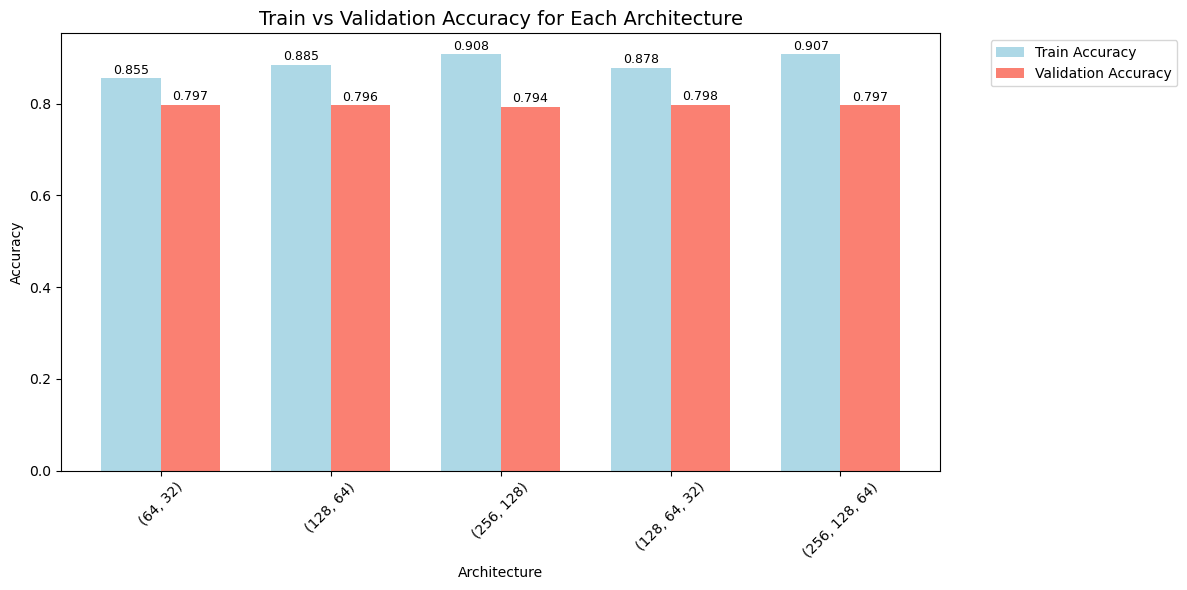

In [29]:
# see distribution of balanced accuracy scores in the training and validation set across different architectures
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df["architecture"]))
bar_width = 0.35
plt.bar(x - bar_width/2, results_df["train_accuracy"], width=bar_width, label='Train Accuracy', color='lightblue')
plt.bar(x + bar_width/2, results_df["val_accuracy"], width=bar_width, label='Validation Accuracy', color='salmon')
plt.title("Train vs Validation Accuracy for Each Architecture", fontsize=14)
plt.xlabel("Architecture")
plt.ylabel("Accuracy")
# position legend outside the plot area to avoid overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(x, results_df["architecture"], rotation=45)
plt.tight_layout()

# allow user to see the values on top of the bars
for i in range(len(results_df)):
    plt.text(i - bar_width/2, results_df["train_accuracy"].iloc[i] + 0.01, f"{results_df['train_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)
    plt.text(i + bar_width/2, results_df["val_accuracy"].iloc[i] + 0.01, f"{results_df['val_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)

plt.show()

All architectures in the preliminary test had a similar validation balanced accuracy of approximately 0.8. Balanced accuracy is used as the primary metric for comparison because it gives equal weight to both the urban and rural classes. Given that the difference between the train and test balanced accuracy is greater than 5 percent, all architectures tested are likely overfitting on the training data. Thus, simpler architectures with better potential for generalization should be compared.  

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html  
https://iterate.ai/ai-glossary/balanced-accuracy  

In [30]:
learning_rate = 0.005
# the relatively small epoch limit is now a safeguard to prevent overfitting
epoch_limit = 15

seeds = [0, 42, 123, 456, 789]  # different for multiple runs

# Define different architectures to test (number of hidden layers and their sizes)
configs = [
    (32, 16),
    (16, 8),
    (8,4),
    (4,2)
]

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train and evaluate the neural network for each architecture configuration
criterion = nn.CrossEntropyLoss()
data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=64)

for hidden_layers in configs:

    run_metrics = []  # to store metrics for this architecture

    for seed in seeds:
        # Set seeds for reproducibility
        os.environ['PYTHONHASHSEED'] = str(seed)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.use_deterministic_algorithms(True)

        network = NeuralNetwork(
            input_size=input_size,
            list_hidden=hidden_layers,
            activation='relu',
            num_classes=2
        )

        print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}")

        network.create_network()

        optimizer = optim.Adam(network.parameters(), lr=learning_rate)

        training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

        loss_history.append({
            "architecture": hidden_layers,
            "seed": seed,
            "losses": training_losses
        })

        # evaluate on both train and validation sets
        trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
        evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)

        # store metrics of this run
        run_metrics.append({
            "train": trainMetrics,
            "val": evalMetrics
        })

    # compute averages across runs
    avg_train_metrics = {}
    for k, v in run_metrics[0]["train"].items():
        if isinstance(v, dict):  # nested dict
            for subk in v:
                avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
        else:  # simple float
            avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
    
    avg_val_metrics = {}
    for k, v in run_metrics[0]["val"].items():
        if isinstance(v, dict):
            for subk in v:
                avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
        else:
            avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])

    # append averaged results for this architecture
    results.append({
        "architecture": hidden_layers,
        **{"train_" + k: v for k, v in avg_train_metrics.items()},
        **{"val_" + k: v for k, v in avg_val_metrics.items()}
    })


Training Neural Network with hidden layers: (32, 16), seed: 0
Epoch: 1 	Loss: 0.424987
Epoch: 2 	Loss: 0.393273
Epoch: 3 	Loss: 0.385099
Epoch: 4 	Loss: 0.377459
Epoch: 5 	Loss: 0.372067
Epoch: 6 	Loss: 0.365622
Epoch: 7 	Loss: 0.361206
Epoch: 8 	Loss: 0.354755
Epoch: 9 	Loss: 0.350942
Epoch: 10 	Loss: 0.349846
Epoch: 11 	Loss: 0.344953
Epoch: 12 	Loss: 0.342343
Epoch: 13 	Loss: 0.338066
Epoch: 14 	Loss: 0.334940
Epoch: 15 	Loss: 0.333670

Training Neural Network with hidden layers: (32, 16), seed: 42
Epoch: 1 	Loss: 0.424190
Epoch: 2 	Loss: 0.392660
Epoch: 3 	Loss: 0.384160
Epoch: 4 	Loss: 0.376136
Epoch: 5 	Loss: 0.372090
Epoch: 6 	Loss: 0.366647
Epoch: 7 	Loss: 0.361066
Epoch: 8 	Loss: 0.356607
Epoch: 9 	Loss: 0.354158
Epoch: 10 	Loss: 0.349135
Epoch: 11 	Loss: 0.346377
Epoch: 12 	Loss: 0.342350
Epoch: 13 	Loss: 0.338975
Epoch: 14 	Loss: 0.336207
Epoch: 15 	Loss: 0.333600

Training Neural Network with hidden layers: (32, 16), seed: 123
Epoch: 1 	Loss: 0.426543
Epoch: 2 	Loss: 0.393

Training loss across epochs for each architecture is visualized in a line graph. The architecture (32,16) has a faster drop in loss than (16,8). Both have noticeably less drop in training loss across epochs compared to the previously evaluated models.

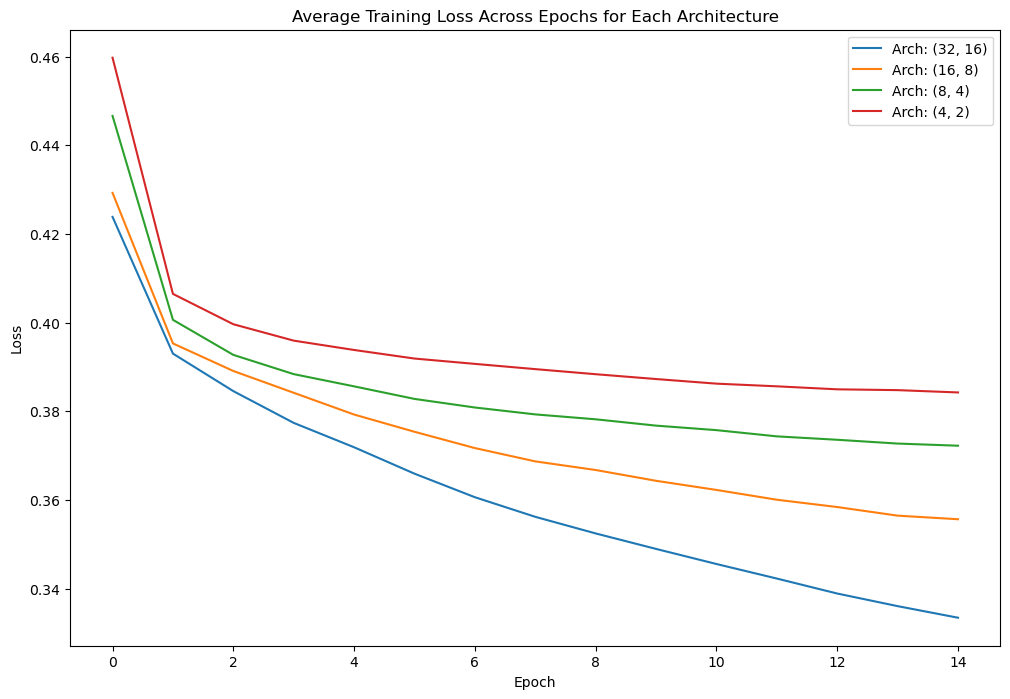

In [31]:
# graph loss history for each architecture (averaged across seeds)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for config in configs:
    # filter loss history for this architecture
    config_history = [h for h in loss_history if h["architecture"] == config]

    min_len = min(len(h["losses"]) for h in config_history)

    aligned_losses = [
        h["losses"][:min_len] for h in config_history
    ]
    
    # average losses across seeds
    avg_losses = np.mean(aligned_losses, axis=0)
    
    plt.plot(avg_losses, label=f"Arch: {config}")

plt.title("Average Training Loss Across Epochs for Each Architecture")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [32]:
# results_flat = []
# for r in results:
#     flat_r = {
#         "architecture": r["architecture"],
#         "train_accuracy": r["train_accuracy"],
#         "train_precision_rural": r["train_precision_class 0"],
#         "train_precision_urban": r["train_precision_class 1"],
#         "train_recall_rural": r["train_recall_class 0"],
#         "train_recall_urban": r["train_recall_class 1"],
#         "train_f1_rural": r["train_f1_class 0"],
#         "train_f1_urban": r["train_f1_class 1"],
#         "val_accuracy": r["val_accuracy"],
#         "val_precision_rural": r["val_precision_class 0"],
#         "val_precision_urban": r["val_precision_class 1"],
#         "val_recall_rural": r["val_recall_class 0"],
#         "val_recall_urban": r["val_recall_class 1"],
#         "val_f1_rural": r["val_f1_class 0"],
#         "val_f1_urban": r["val_f1_class 1"],
#         "PR_AUC": r["PR_AUC"],
#         "ROC_AUC": r["PR_AUC"]
#     }
#     results_flat.append(flat_r)

results_flat = flat_results_architecture(results)
results_df = pd.DataFrame(results_flat)
results_df.T

,0,1,2,3
architecture,"(32, 16)","(16, 8)","(8, 4)","(4, 2)"
train_accuracy,0.836548,0.826709,0.815337,0.803363
train_precision_rural,0.858241,0.856323,0.846546,0.82978
train_precision_urban,0.850916,0.819697,0.808892,0.825562
train_recall_rural,0.917813,0.896313,0.891485,0.90772
train_recall_urban,0.755283,0.757104,0.739188,0.699006
train_f1_rural,0.886981,0.875748,0.868376,0.86682
train_f1_urban,0.800088,0.786817,0.772296,0.756331
train_log_loss,0.321282,0.348701,0.368183,0.381007
train_ROC_AUC,0.929245,0.915804,0.903329,0.89633


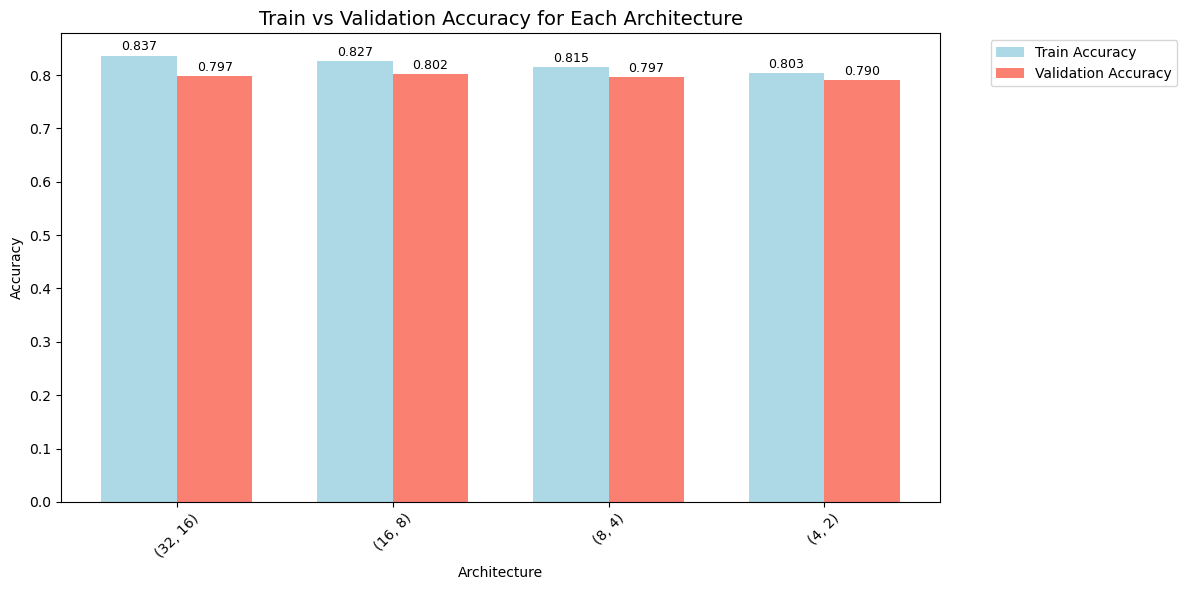

In [33]:
# see distribution of balanced accuracy scores in the training and validation set across different architectures
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df["architecture"]))
bar_width = 0.35
plt.bar(x - bar_width/2, results_df["train_accuracy"], width=bar_width, label='Train Accuracy', color='lightblue')
plt.bar(x + bar_width/2, results_df["val_accuracy"], width=bar_width, label='Validation Accuracy', color='salmon')
plt.title("Train vs Validation Accuracy for Each Architecture", fontsize=14)
plt.xlabel("Architecture")
plt.ylabel("Accuracy")
# position legend outside the plot area to avoid overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(x, results_df["architecture"], rotation=45)
plt.tight_layout()

# allow user to see the values on top of the bars
for i in range(len(results_df)):
    plt.text(i - bar_width/2, results_df["train_accuracy"].iloc[i] + 0.01, f"{results_df['train_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)
    plt.text(i + bar_width/2, results_df["val_accuracy"].iloc[i] + 0.01, f"{results_df['val_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)

The smaller architectures show lesser differences between training and validation balanced accuracies, indicating that they are able to better identify the correct label without overfitting. Moreover, both models exhibit similar validation balanced accuracies of around 0.80.

By the principle of Occam's Razor, it is therefore justified to select the neural network with the lesser neurons among them as this would lead to a similar result as the other, only with less memory consumption.

https://www.geeksforgeeks.org/machine-learning/occams-razor/

Thus, we proceed to fine tine the neural network with 2 hidden layers having a configuration of 4 and 2 neurons respectively.

### Comparison of different Hyperparameter Configurations

Performance of the model on different configurations of learning rates and batch sizes are compared.

In [56]:
# increase epoch limit to observe convergence behavior of smaller architectures
epoch_limit = 100
learning_rates = [0.001, 0.005, 0.01]
batch_sizes = [32, 64, 128]

seeds = [0]  # using only one seed to save time.

# Only use one architecture
configs = [
    (4,2)
]

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train for each learning rate and batch size combination
for lr in learning_rates:
    for bs in batch_sizes:

        # Train and evaluate the neural network for each architecture configuration
        criterion = nn.CrossEntropyLoss()
        data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=bs)

        for hidden_layers in configs:

            run_metrics = []  # to store metrics for this architecture

            for seed in seeds:
                # Set seed for reproducibility
                os.environ['PYTHONHASHSEED'] = str(seed)
                random.seed(seed)
                np.random.seed(seed)
                torch.manual_seed(seed)
                torch.use_deterministic_algorithms(True)

                network = NeuralNetwork(
                    input_size=input_size,
                    list_hidden=hidden_layers,
                    activation='relu',
                    num_classes=2
                )

                print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}, learning rate: {lr}, batch size: {bs}")

                network.create_network()

                optimizer = optim.Adam(network.parameters(), lr=lr)

                training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

                loss_history.append({
                    "architecture": hidden_layers,
                    "seed": seed,
                    "learning_rate": lr,
                    "batch_size": bs,
                    "losses": training_losses
                })

                # evaluate on both train and validation sets
                trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
                evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)

                # store metrics of this run
                run_metrics.append({
                    "train": trainMetrics,
                    "val": evalMetrics
                })

            # compute averages across runs
            avg_train_metrics = {}
            for k, v in run_metrics[0]["train"].items():
                if isinstance(v, dict):  # nested dict
                    for subk in v:
                        avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
                else:  # simple float
                    avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
            
            avg_val_metrics = {}
            for k, v in run_metrics[0]["val"].items():
                if isinstance(v, dict):
                    for subk in v:
                        avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
                else:
                    avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])

            # append averaged results for this architecture
            results.append({
                "architecture": hidden_layers,
                "learning_rate": lr,
                "batch_size": bs,
                **{"train_" + k: v for k, v in avg_train_metrics.items()},
                **{"val_" + k: v for k, v in avg_val_metrics.items()}
            })


Training Neural Network with hidden layers: (4, 2), seed: 0, learning rate: 0.001, batch size: 32
Epoch: 1 	Loss: 0.508096
Epoch: 2 	Loss: 0.434199
Epoch: 3 	Loss: 0.419416
Epoch: 4 	Loss: 0.411843
Epoch: 5 	Loss: 0.406531
Epoch: 6 	Loss: 0.402580
Epoch: 7 	Loss: 0.399386
Epoch: 8 	Loss: 0.396584
Epoch: 9 	Loss: 0.394510
Epoch: 10 	Loss: 0.393583
Epoch: 11 	Loss: 0.391815
Epoch: 12 	Loss: 0.391034
Epoch: 13 	Loss: 0.389492
Epoch: 14 	Loss: 0.388787
Epoch: 15 	Loss: 0.387883
Epoch: 16 	Loss: 0.387227
Epoch: 17 	Loss: 0.387034
Epoch: 18 	Loss: 0.386036
Epoch: 19 	Loss: 0.384873
Epoch: 20 	Loss: 0.384805
Epoch: 21 	Loss: 0.384600
Epoch: 22 	Loss: 0.384503
Epoch: 23 	Loss: 0.383838
Epoch: 24 	Loss: 0.383010
Epoch: 25 	Loss: 0.383416
Epoch: 26 	Loss: 0.382684
Epoch: 27 	Loss: 0.382168
Epoch: 28 	Loss: 0.382636
Epoch: 29 	Loss: 0.382507
Epoch: 30 	Loss: 0.381893
Epoch: 31 	Loss: 0.381694
Epoch: 32 	Loss: 0.381410
Epoch: 33 	Loss: 0.381085
Epoch: 34 	Loss: 0.381372
Epoch: 35 	Loss: 0.380611


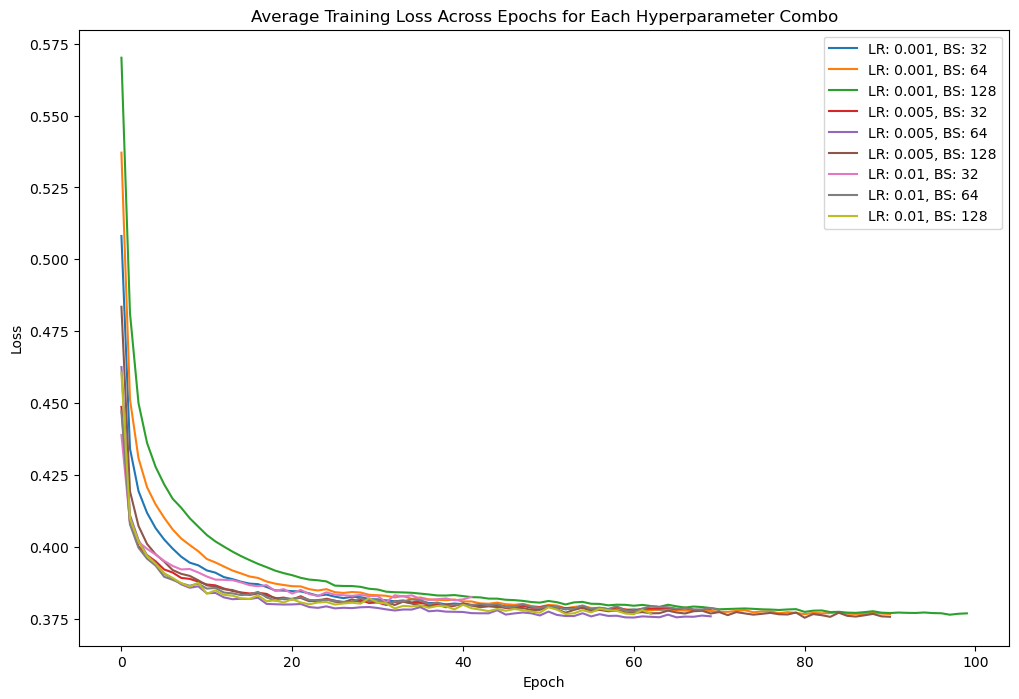

In [57]:
# graph loss history for each learning rate and batch size combination
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for lr in learning_rates:
    for bs in batch_sizes:
        # filter loss history for this learning rate and batch size
        config_history = [h for h in loss_history if h["architecture"] == (4, 2) and h["seed"] == 0 and h["learning_rate"] == lr and h["batch_size"] == bs]

        min_len = min(len(h["losses"]) for h in config_history)

        aligned_losses = [
            h["losses"][:min_len] for h in config_history
        ]
        
        # average losses across seeds
        avg_losses = np.mean(aligned_losses, axis=0)
        
        plt.plot(avg_losses, label=f"LR: {lr}, BS: {bs}")

plt.title("Average Training Loss Across Epochs for Each Hyperparameter Combo")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Among all the possible configurations, the model that used a learning rate of 0.01 and a batch size of 32 had the fastest convergence at epoch 42.

The metrics for comparing the different configurations are displayed in table form. Balanced accuracies and f1 scores are visualized with a bar chart.

In [58]:
# flatten results for viewing
def flat_results_LR_BS(results_to_flatten):
    results_flat = []
    for r in results_to_flatten:
        flat_r = {
            "learning_rate": r["learning_rate"],
            "batch_size": r["batch_size"],
            "train_accuracy": r["train_accuracy"],
            "train_precision_rural": r["train_precision_class 0"],
            "train_precision_urban": r["train_precision_class 1"],
            "train_recall_rural": r["train_recall_class 0"],
            "train_recall_urban": r["train_recall_class 1"],
            "train_f1_rural": r["train_f1_class 0"],
            "train_f1_urban": r["train_f1_class 1"],
            "train_log_loss": r["train_log_loss"],
            "train_ROC_AUC": r["train_ROC_AUC"],
            "train_PR_AUC": r["train_PR_AUC"],
            "val_accuracy": r["val_accuracy"],
            "val_precision_rural": r["val_precision_class 0"],
            "val_precision_urban": r["val_precision_class 1"],
            "val_recall_rural": r["val_recall_class 0"],
            "val_recall_urban": r["val_recall_class 1"],
            "val_f1_rural": r["val_f1_class 0"],
            "val_f1_urban": r["val_f1_class 1"],
            "val_log_loss": r["val_log_loss"],
            "val_ROC_AUC": r["val_ROC_AUC"],
            "val_PR_AUC": r["val_PR_AUC"],
        }
        results_flat.append(flat_r)
    return results_flat

In [59]:
results_flat = flat_results_LR_BS(results)
results_df = pd.DataFrame(results_flat)
results_df.T

,0,1,2,3,4,5,6,7,8
learning_rate,0.001000,0.001000,0.001000,0.005000,0.005000,0.005000,0.010000,0.010000,0.010000
batch_size,32.000000,64.000000,128.000000,32.000000,64.000000,128.000000,32.000000,64.000000,128.000000
train_accuracy,0.802614,0.811808,0.808738,0.815518,0.799953,0.814518,0.815843,0.801675,0.810663
train_precision_rural,0.825747,0.839916,0.834365,0.852565,0.821134,0.850393,0.848690,0.823327,0.837313
train_precision_urban,0.837957,0.818297,0.827478,0.789632,0.847806,0.792681,0.802985,0.845239,0.823699
train_recall_rural,0.917560,0.900449,0.908342,0.875158,0.924876,0.878269,0.886680,0.922745,0.904943
train_recall_urban,0.687668,0.723167,0.709135,0.755878,0.675030,0.750767,0.745005,0.680606,0.716383
train_f1_rural,0.869235,0.869130,0.869783,0.863714,0.869923,0.864107,0.867270,0.870205,0.869816
train_f1_urban,0.755410,0.767796,0.763749,0.772386,0.751617,0.771154,0.772909,0.754041,0.766302
train_log_loss,0.376371,0.374965,0.375096,0.380431,0.375672,0.376285,0.377639,0.380724,0.373504


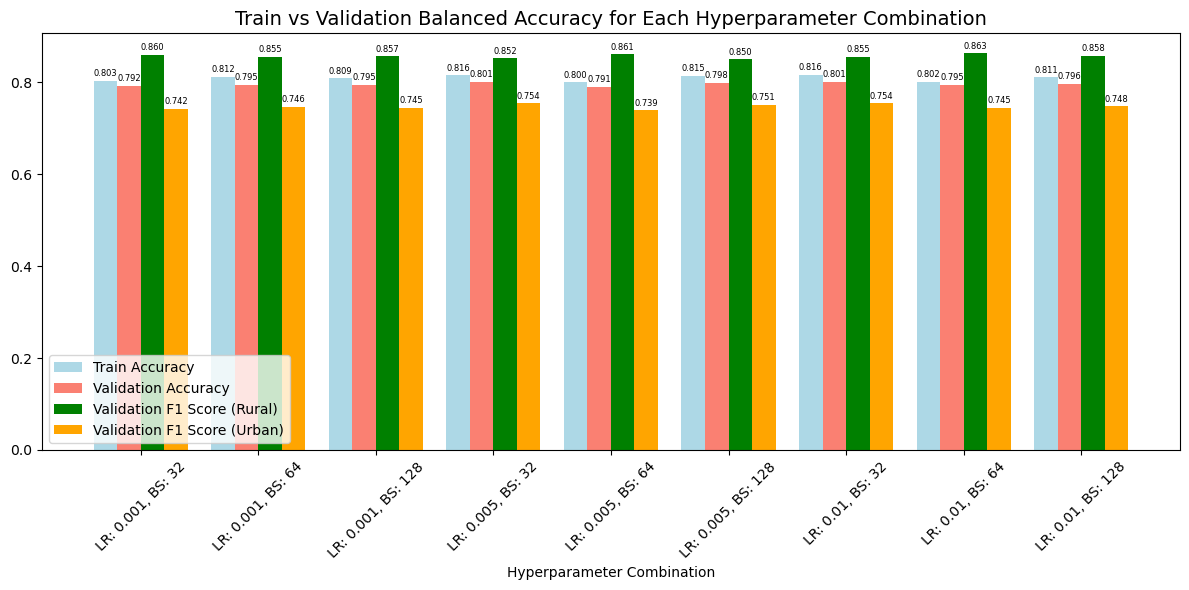

In [60]:
# see comparison of balanced accuracy scores in the training and validation set and f1 scores across
# different combinations of learning rate and batch size using a bar chart
plt.figure(figsize=(12, 6))

# x-axis positions
x = np.arange(len(results_df))

bar_width = 0.2

# Plot bars
plt.bar(x - 1.5*bar_width, results_df["train_accuracy"], width=bar_width, label='Train Accuracy', color='lightblue')
plt.bar(x - 0.5*bar_width, results_df["val_accuracy"], width=bar_width, label='Validation Accuracy', color='salmon')
plt.bar(x + 0.5*bar_width, results_df["val_f1_rural"], width=bar_width, label='Validation F1 Score (Rural)', color='green')
plt.bar(x + 1.5*bar_width, results_df["val_f1_urban"], width=bar_width, label='Validation F1 Score (Urban)', color='orange')

# Titles and labels
plt.title("Train vs Validation Balanced Accuracy for Each Hyperparameter Combination", fontsize=14)
plt.xlabel("Hyperparameter Combination")
plt.ylabel(None)
plt.legend()

# X-axis labels
plt.xticks(
    x, 
    [f"LR: {lr}, BS: {bs}" for lr, bs in zip(results_df["learning_rate"], results_df["batch_size"])], 
    rotation=45
)

# Show values on top of bars
for i in range(len(results_df)):
    plt.text(i - 1.5*bar_width, results_df["train_accuracy"].iloc[i] + 0.01, f"{results_df['train_accuracy'].iloc[i]:.3f}", ha='center', fontsize=6)
    plt.text(i - 0.5*bar_width, results_df["val_accuracy"].iloc[i] + 0.01, f"{results_df['val_accuracy'].iloc[i]:.3f}", ha='center', fontsize=6)
    plt.text(i + 0.5*bar_width, results_df["val_f1_rural"].iloc[i] + 0.01, f"{results_df['val_f1_rural'].iloc[i]:.3f}", ha='center', fontsize=6)
    plt.text(i + 1.5*bar_width, results_df["val_f1_urban"].iloc[i] + 0.01, f"{results_df['val_f1_urban'].iloc[i]:.3f}", ha='center', fontsize=6)

plt.tight_layout()
plt.show()

All hyperparameter configurations tested using the architecture (4,2) resulted in similar training and validation balanced accuracies within 0.80 &plusmn; 0.02. The minimal difference between training and validation accuracies indicate that these models were also able to learn how to classify urban and rural households without overfitting on training data.

Although accuracies and f1 scores of each configuration is similar to one another, the model that trained with a learning rate 0.01 and batch size 32 will be used as it was able to converge within the least number of epochs.

# **[6]** Model Evaluation

Now that the final configurations have been identified, the final model is trained, evaluated, and tested using these configurations and its weights are saved.

In [61]:
# increase epoch limit to observe convergence behavior of smaller architectures
epoch_limit = 100

# this time we only use one configuration
learning_rates = [0.01]
batch_sizes = [32]
seeds = [0]  # using seed for reproduciblity

# Only use one architecture
configs = [
    (4,2)
]

# list to store final weights of the trained model
weights = []

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train for each learning rate and batch size combination
for lr in learning_rates:
    for bs in batch_sizes:

        # Train and evaluate the neural network for each architecture configuration
        criterion = nn.CrossEntropyLoss()
        data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=bs)

        for hidden_layers in configs:

            run_metrics = []  # to store metrics for this architecture

            for seed in seeds:
                # Set seed for reproducibility
                os.environ['PYTHONHASHSEED'] = str(seed)
                random.seed(seed)
                np.random.seed(seed)
                torch.manual_seed(seed)
                torch.use_deterministic_algorithms(True)

                network = NeuralNetwork(
                    input_size=input_size,
                    list_hidden=hidden_layers,
                    activation='relu',
                    num_classes=2
                )

                print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}, learning rate: {lr}, batch size: {bs}")

                network.create_network()

                optimizer = optim.Adam(network.parameters(), lr=lr)

                training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

                loss_history.append({
                    "architecture": hidden_layers,
                    "seed": seed,
                    "learning_rate": lr,
                    "batch_size": bs,
                    "losses": training_losses
                })

                # evaluate on train, validation, and test sets
                trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
                evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)
                testMetrics = evaluateNetwork(network, nn_X_test, nn_y_test)

                # store metrics of this run
                run_metrics.append({
                    "train": trainMetrics,
                    "val": evalMetrics,
                    "test": testMetrics
                })

            # compute averages across runs
            avg_train_metrics = {}
            for k, v in run_metrics[0]["train"].items():
                if isinstance(v, dict):  # nested dict
                    for subk in v:
                        avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
                else:  # simple float
                    avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
            
            avg_val_metrics = {}
            for k, v in run_metrics[0]["val"].items():
                if isinstance(v, dict):
                    for subk in v:
                        avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
                else:
                    avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])

            avg_test_metrics = {}
            for k, v in run_metrics[0]["test"].items():
                if isinstance(v, dict):
                    for subk in v:
                        avg_test_metrics[f"{k}_{subk}"] = np.mean([r["test"][k][subk] for r in run_metrics])
                else:
                    avg_test_metrics[k] = np.mean([r["test"][k] for r in run_metrics])

            # append averaged results for this architecture
            results.append({
                "architecture": hidden_layers,
                "learning_rate": lr,
                "batch_size": bs,
                **{"train_" + k: v for k, v in avg_train_metrics.items()},
                **{"val_" + k: v for k, v in avg_val_metrics.items()},
                **{"test_" + k: v for k, v in avg_test_metrics.items()}
            })
            
            # store final weights of the trained model
            weights.append({
                "architecture": hidden_layers,
                "seed": seed,
                "learning_rate": lr,
                "batch_size": bs,
                "final_weights": network.state_dict()
            })


Training Neural Network with hidden layers: (4, 2), seed: 0, learning rate: 0.01, batch size: 32
Epoch: 1 	Loss: 0.438870
Epoch: 2 	Loss: 0.408694
Epoch: 3 	Loss: 0.401738
Epoch: 4 	Loss: 0.399302
Epoch: 5 	Loss: 0.397321
Epoch: 6 	Loss: 0.395129
Epoch: 7 	Loss: 0.393374
Epoch: 8 	Loss: 0.392150
Epoch: 9 	Loss: 0.392298
Epoch: 10 	Loss: 0.391108
Epoch: 11 	Loss: 0.389696
Epoch: 12 	Loss: 0.388616
Epoch: 13 	Loss: 0.388534
Epoch: 14 	Loss: 0.388406
Epoch: 15 	Loss: 0.387645
Epoch: 16 	Loss: 0.386685
Epoch: 17 	Loss: 0.386327
Epoch: 18 	Loss: 0.386689
Epoch: 19 	Loss: 0.384686
Epoch: 20 	Loss: 0.385312
Epoch: 21 	Loss: 0.383748
Epoch: 22 	Loss: 0.385044
Epoch: 23 	Loss: 0.383580
Epoch: 24 	Loss: 0.382931
Epoch: 25 	Loss: 0.384194
Epoch: 26 	Loss: 0.383379
Epoch: 27 	Loss: 0.383181
Epoch: 28 	Loss: 0.382981
Epoch: 29 	Loss: 0.383299
Epoch: 30 	Loss: 0.382888
Epoch: 31 	Loss: 0.382906
Epoch: 32 	Loss: 0.380733
Epoch: 33 	Loss: 0.383176
Epoch: 34 	Loss: 0.382744
Epoch: 35 	Loss: 0.383152
E

In [62]:
# Name of the directory to save to
dir_name = "processed_data"

# Ensure the directory exists
os.makedirs(dir_name, exist_ok=True)

# Full path to save the file
file_path = os.path.join(dir_name, "final_neural_network_weights.pkl")

# Save the weights
joblib.dump(weights, file_path)
print(f"Model saved to {file_path}")

Model saved to processed_data\final_neural_network_weights.pkl


In [67]:
# flatten results for viewing include training metrics
results_flat = []
for r in results:
    flat_r = {
        "learning_rate": r["learning_rate"],
        "batch_size": r["batch_size"],
        "train_accuracy": r["train_accuracy"],
        "train_precision_rural": r["train_precision_class 0"],
        "train_precision_urban": r["train_precision_class 1"],
        "train_recall_rural": r["train_recall_class 0"],
        "train_recall_urban": r["train_recall_class 1"],
        "train_f1_rural": r["train_f1_class 0"],
        "train_f1_urban": r["train_f1_class 1"],
        "train_log_loss": r["train_log_loss"],
        "train_ROC_AUC": r["train_ROC_AUC"],
        "train_PR_AUC": r["train_PR_AUC"],
        "val_accuracy": r["val_accuracy"],
        "val_precision_rural": r["val_precision_class 0"],
        "val_precision_urban": r["val_precision_class 1"],
        "val_recall_rural": r["val_recall_class 0"],
        "val_recall_urban": r["val_recall_class 1"],
        "val_f1_rural": r["val_f1_class 0"],
        "val_f1_urban": r["val_f1_class 1"],
        "val_log_loss": r["val_log_loss"],
        "val_ROC_AUC": r["val_ROC_AUC"],
        "val_PR_AUC": r["val_PR_AUC"],
        "test_accuracy": r["test_accuracy"],
        "test_precision_rural": r["test_precision_class 0"],
        "test_precision_urban": r["test_precision_class 1"],
        "test_recall_rural": r["test_recall_class 0"],
        "test_recall_urban": r["test_recall_class 1"],
        "test_f1_rural": r["test_f1_class 0"],
        "test_f1_urban": r["test_f1_class 1"],
        "test_log_loss": r["test_log_loss"],
        "test_ROC_AUC": r["test_ROC_AUC"],
        "test_PR_AUC": r["test_PR_AUC"],
    }
    results_flat.append(flat_r)

results_df = pd.DataFrame(results_flat)
results_df.T

,0
learning_rate,0.010000
batch_size,32.000000
train_accuracy,0.815843
train_precision_rural,0.848690
train_precision_urban,0.802985
train_recall_rural,0.886680
train_recall_urban,0.745005
train_f1_rural,0.867270
train_f1_urban,0.772909
train_log_loss,0.377639


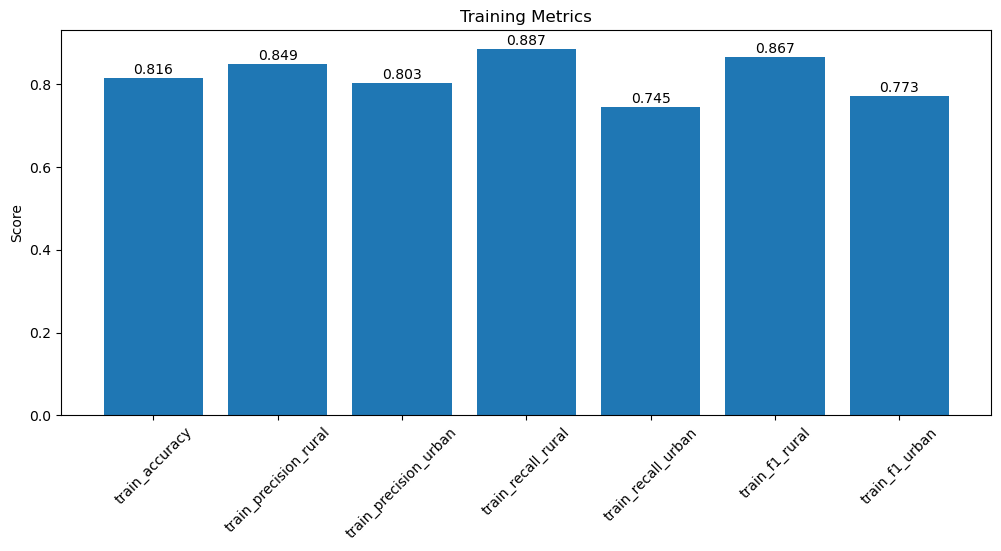

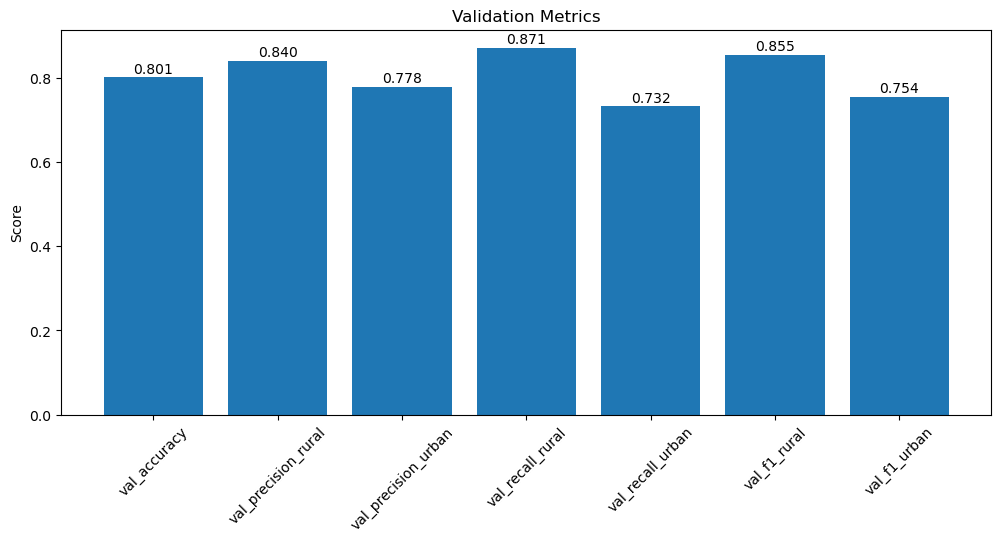

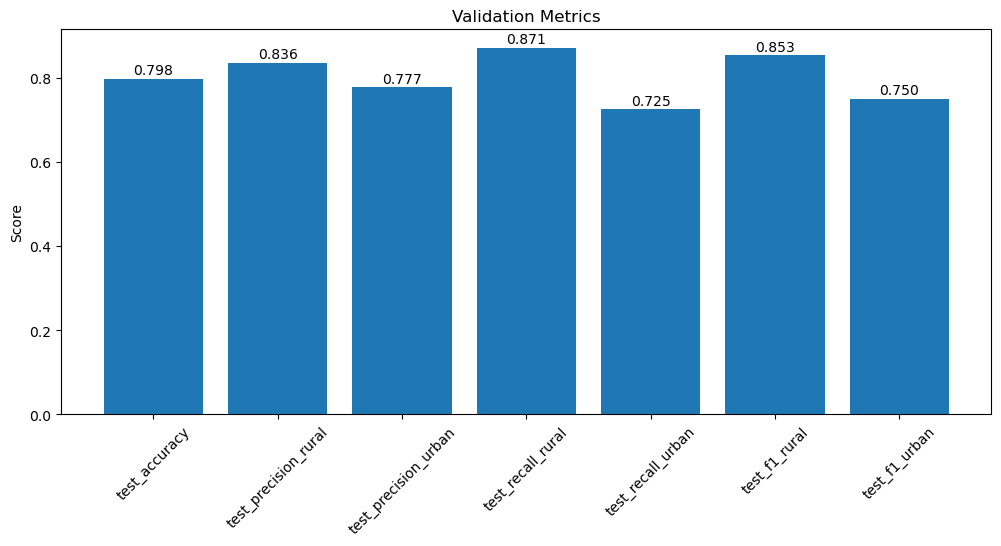

In [68]:
train_output = results_df[["train_accuracy","train_precision_rural","train_precision_urban","train_recall_rural","train_recall_urban","train_f1_rural","train_f1_urban"]]

row = train_output.iloc[0] 

metrics = row.index
values = row.values

x = np.arange(len(metrics))

plt.figure(figsize=(12, 5))
plt.bar(x, values)

plt.xticks(x, metrics, rotation=45)
plt.ylabel("Score")
plt.title("Training Metrics")

# Value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

val_output = results_df[["val_accuracy","val_precision_rural","val_precision_urban","val_recall_rural","val_recall_urban","val_f1_rural","val_f1_urban"]]
val_output

row = val_output.iloc[0] 

metrics = row.index
values = row.values

x = np.arange(len(metrics))

plt.figure(figsize=(12, 5))
plt.bar(x, values)

plt.xticks(x, metrics, rotation=45)
plt.ylabel("Score")
plt.title("Validation Metrics")

# Value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

test_output = results_df[["test_accuracy","test_precision_rural","test_precision_urban","test_recall_rural","test_recall_urban","test_f1_rural","test_f1_urban"]]

row = test_output.iloc[0] 

metrics = row.index
values = row.values

x = np.arange(len(metrics))

plt.figure(figsize=(12, 5))
plt.bar(x, values)

plt.xticks(x, metrics, rotation=45)
plt.ylabel("Score")
plt.title("Validation Metrics")

# Value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

The final multi-layer perceptron was able to achieve a balanced accuracy within 0.80 &plusmn; 0.02 across all set partitions. This indicates that it was able to successfully learn how to classify urban and rural households without overfitting on the training set.

<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA

Tan, Jeremy James Teves
- Uses ChatGPT to clarify proper flow for training loop
- Uses ChatGPT to assist with understanding errors that came up during debugging
- Uses ChatGPT to clarify errors in python syntax for neural network implementation and training
- Uses Google-search which has AI features in finding sources to justify approaches